# Cloud Segmentation — Inference & Visualisation

Affiche pour chaque image de test :
- **Image du ciel** (originale)
- **Masque ground truth** (blanc = nuage, noir = ciel)
- **Masque prédit** (blanc = nuage, noir = ciel)

Calcule aussi le F1 et la couverture nuageuse sur le jeu de test.

In [1]:
import sys, os, random
from pathlib import Path

import numpy as np
import cv2
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

from predict import predict_mask
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

c:\Users\romai\anaconda3\envs\saillowtech1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Modifie les chemins si nécessaire.

In [2]:
CHECKPOINT  = "./checkpoints/best_model.pth"   # chemin vers le checkpoint
TEST_DIR    = "../dataset/test"                # dossier images de test
LABELS_DIR  = "../dataset/test_labels"         # dossier GT (None pour désactiver)

N_IMAGES    = 15       # nombre d'images à afficher
THRESHOLD   = 0.5     # seuil de probabilité pour cloud
SEED        = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")

Device : cuda


## Chargement du modèle

In [3]:
def load_model(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    cfg  = ckpt["model_config"]
    ModelClass = getattr(smp, cfg["architecture"])
    model = ModelClass(
        encoder_name    = cfg["encoder_name"],
        encoder_weights = None,
        in_channels     = cfg["in_channels"],
        classes         = cfg["classes"],
    ).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    image_size = ckpt.get("image_size", 384)
    print(f"Modèle : {cfg['architecture']} ({cfg['encoder_name']})")
    print(f"Image size : {image_size}")
    if "iou" in ckpt:
        print(f"Best val IoU : {ckpt['iou']:.4f}   Dice : {ckpt.get('dice', 0):.4f}")
    return model, image_size

model, IMAGE_SIZE = load_model(CHECKPOINT, DEVICE)

Modèle : Unet (resnet34)
Image size : 384
Best val IoU : 0.8881   Dice : 0.9376


## Fonctions utilitaires

In [4]:
def get_transform(image_size):
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

@torch.no_grad()

def load_gt(path):
    """Charge un masque GT. Convention dataset : white(255)=nuage → 1, black(0)=ciel → 0."""
    g = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    return (g >= 128).astype(np.uint8) if g is not None else None

def coverage(mask):
    return 100.0 * mask.sum() / mask.size

TRANSFORM = get_transform(IMAGE_SIZE)
print("Fonctions chargées.")

Fonctions chargées.


In [5]:
def show_comparison(image_bgr, pred_mask, gt_mask=None, filename=""):
    has_gt = gt_mask is not None
    ncols  = 3 if has_gt else 2
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    cov_pred  = coverage(pred_mask)

    axes[0].imshow(image_rgb)
    axes[0].set_title("Image du ciel", fontsize=12, fontweight="bold")
    axes[0].axis("off")

    if has_gt:
        cov_gt = coverage(gt_mask)

        gt_vis = np.zeros((*gt_mask.shape, 3), dtype=np.uint8)
        gt_vis[gt_mask > 0] = [255, 255, 255]
        axes[1].imshow(gt_vis)
        axes[1].set_title(f"Ground Truth\n☁ {cov_gt:.1f}%", fontsize=12, fontweight="bold")
        axes[1].axis("off")
        pred_ax = axes[2]

        gt_r  = cv2.resize(gt_mask, (pred_mask.shape[1], pred_mask.shape[0]),
                           interpolation=cv2.INTER_NEAREST)
        inter = int((pred_mask & gt_r).sum())
        f1    = (2 * inter + 1e-7) / (pred_mask.sum() + gt_r.sum() + 1e-7)
        pred_title = f"Prédiction  (F1={f1:.3f})\n☁ {cov_pred:.1f}%"
    else:
        pred_ax    = axes[1]
        pred_title = f"Prédiction\n☁ {cov_pred:.1f}%"

    pred_vis = np.zeros((*pred_mask.shape, 3), dtype=np.uint8)
    pred_vis[pred_mask > 0] = [255, 255, 255]
    pred_ax.imshow(pred_vis)
    pred_ax.set_title(pred_title, fontsize=12, fontweight="bold")
    pred_ax.axis("off")

    if filename:
        fig.suptitle(filename, fontsize=9, color="gray", y=1.01)

    plt.tight_layout()
    plt.show()
    return fig

## Visualisation des images de test

Sélection aléatoire de `N_IMAGES` parmi les images du dossier test.

51 images dans le dossier test.


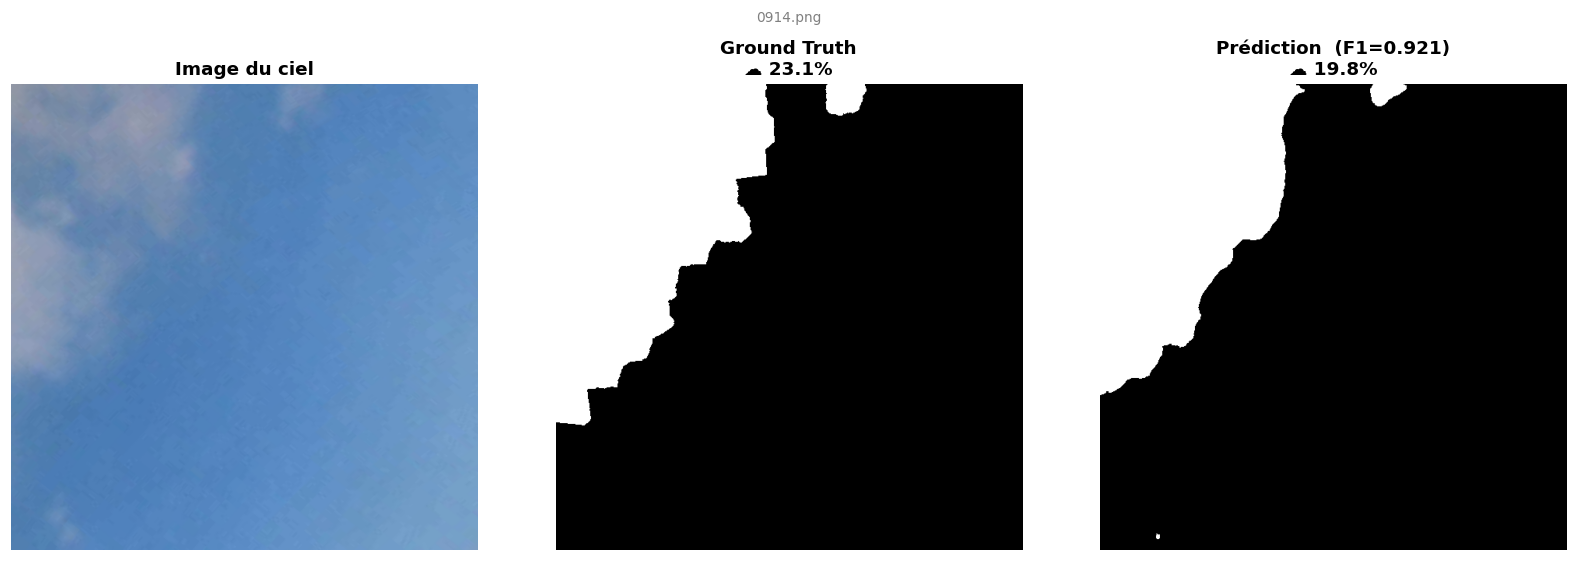

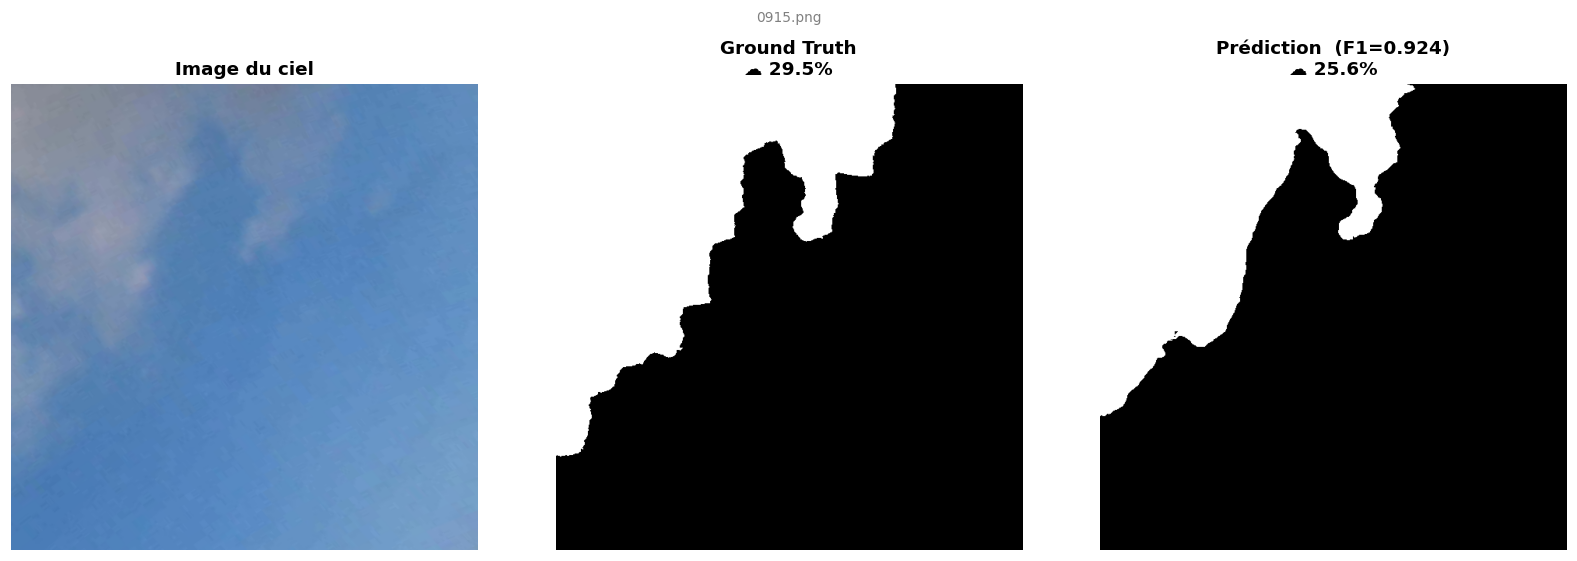

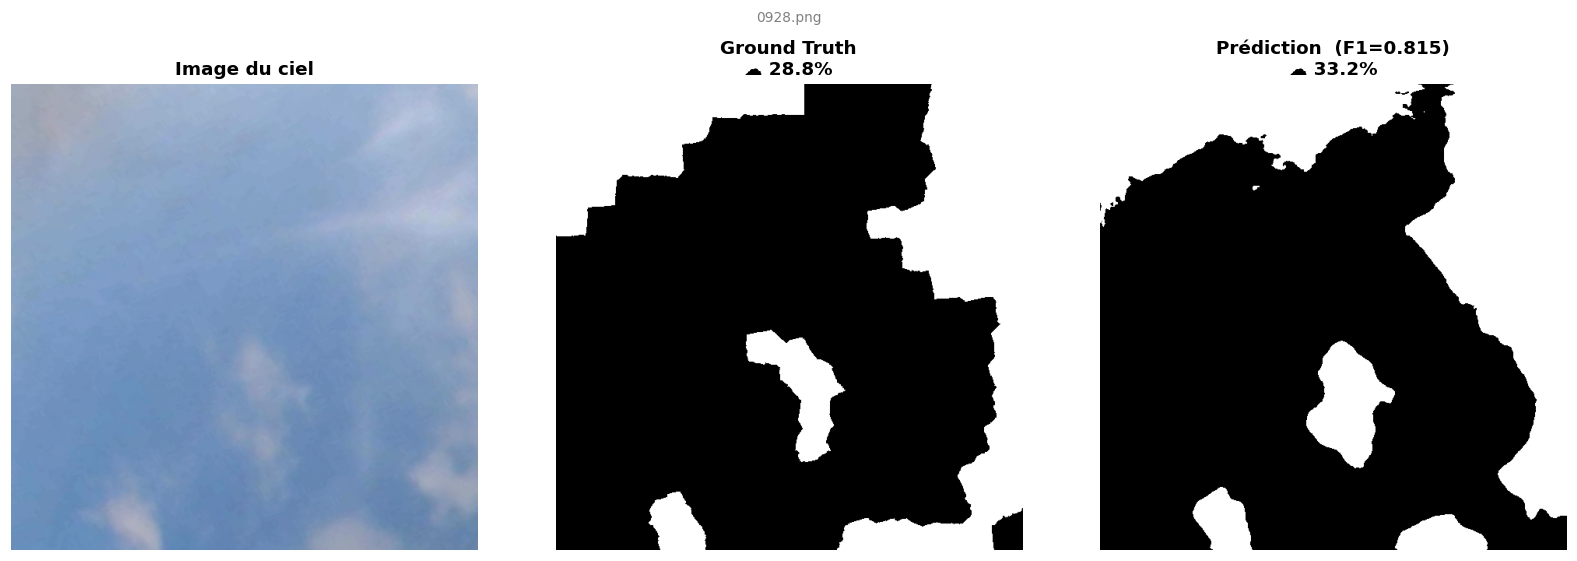

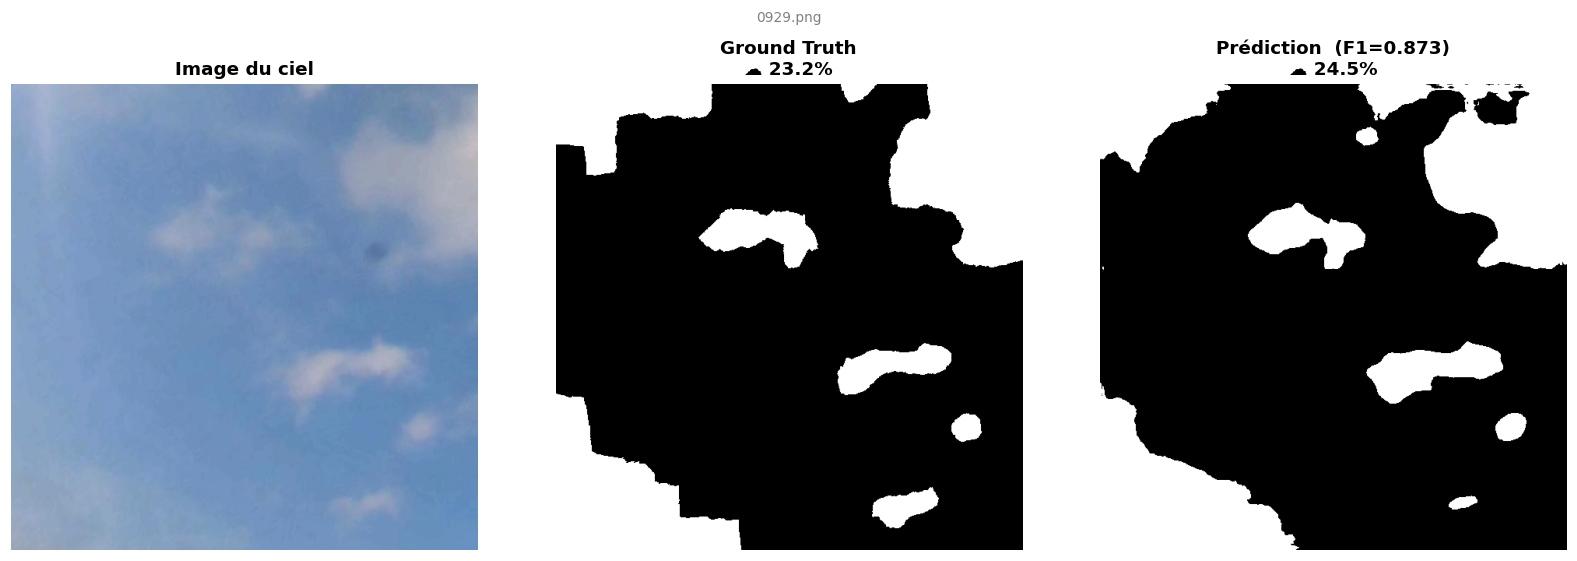

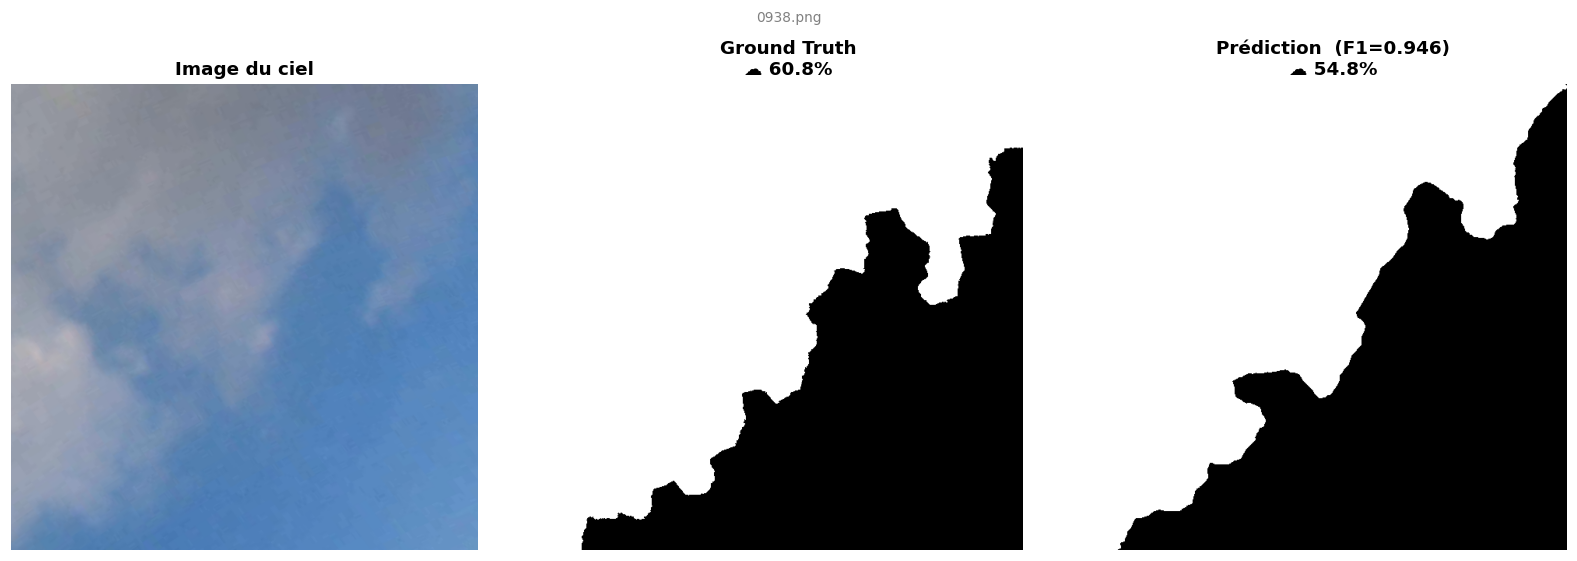

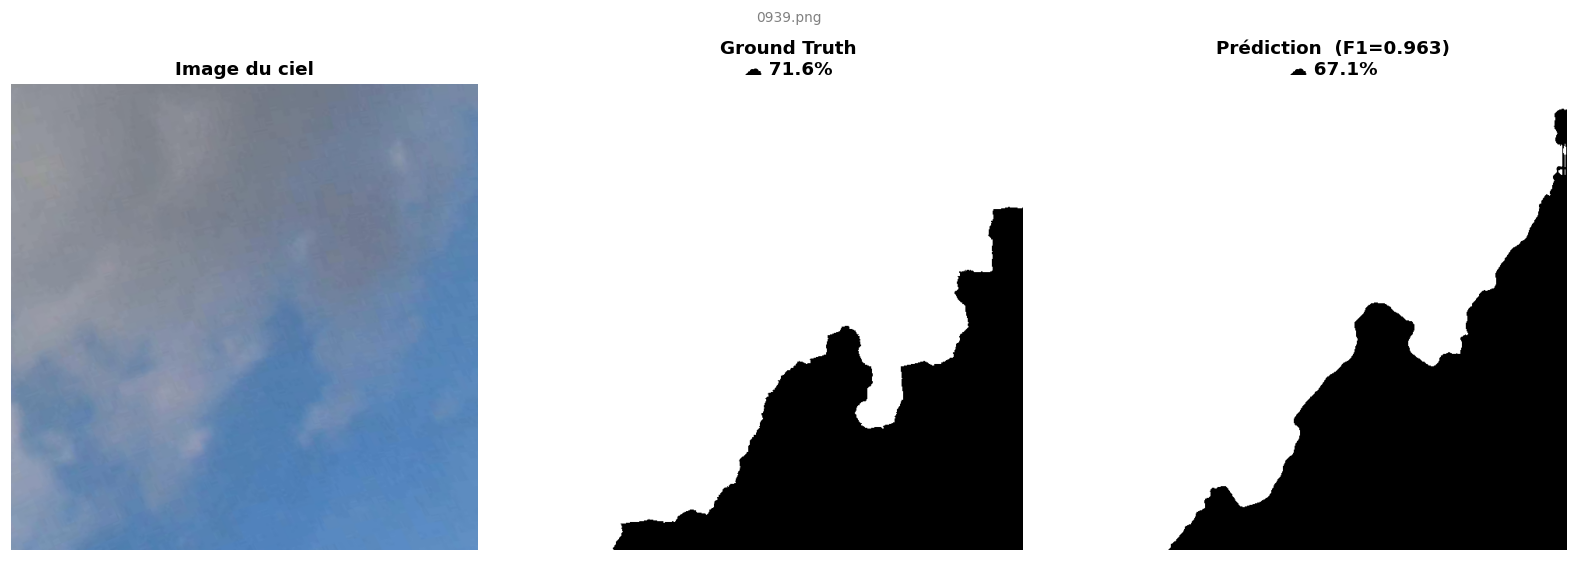

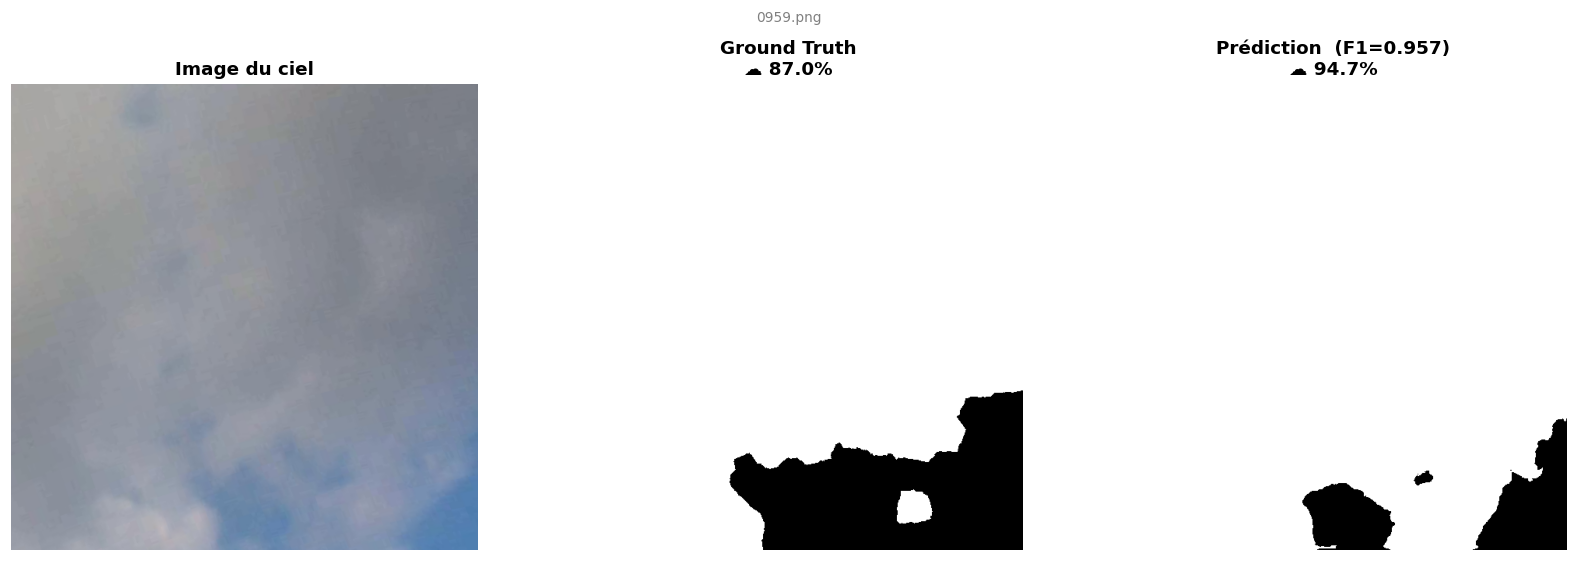

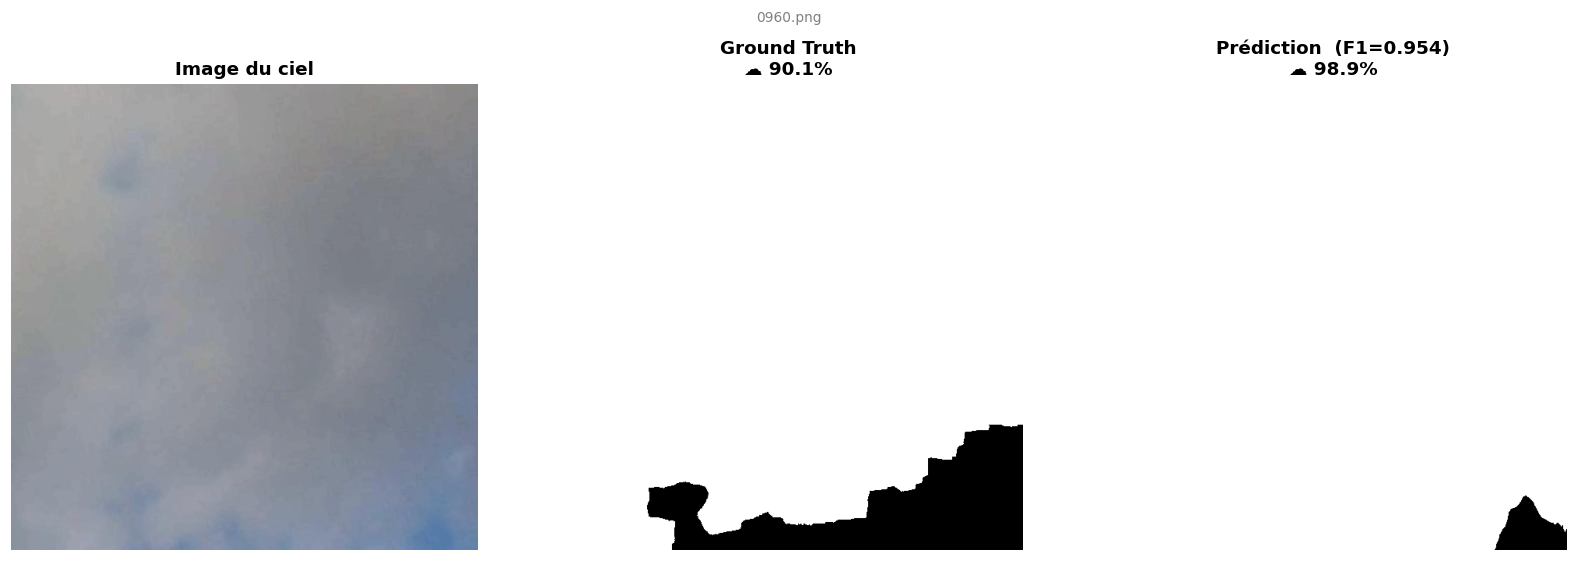

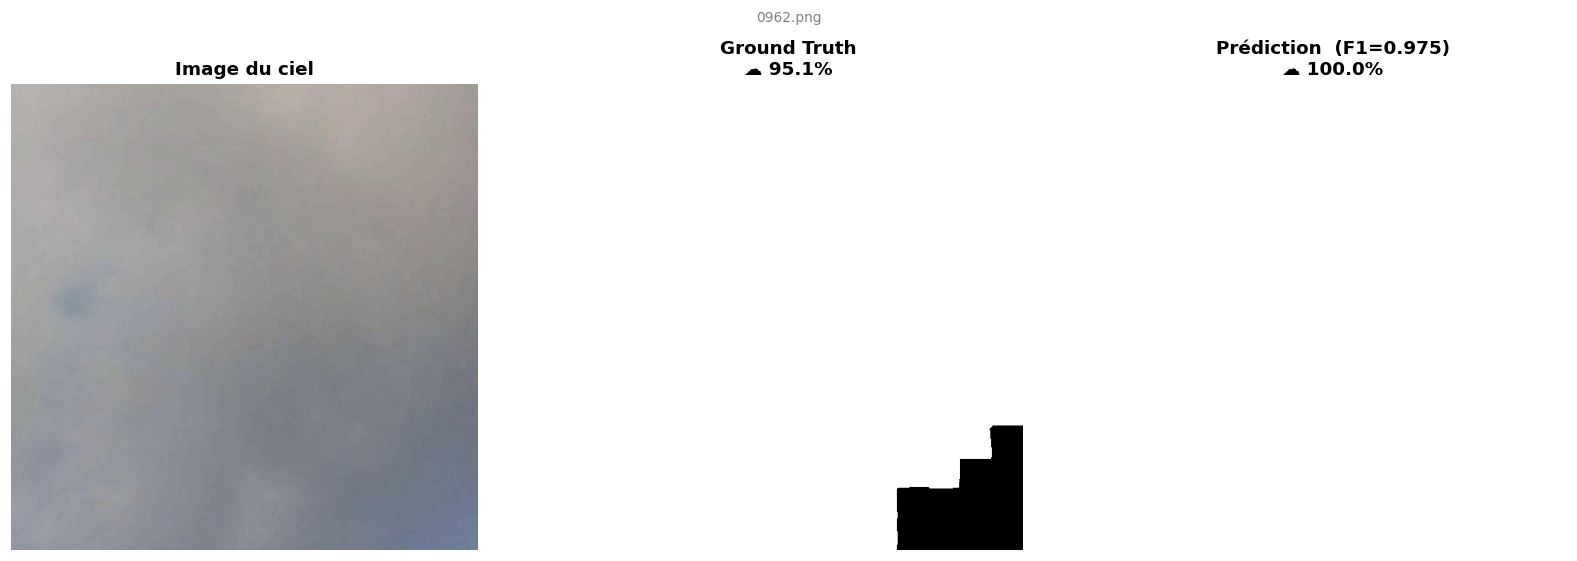

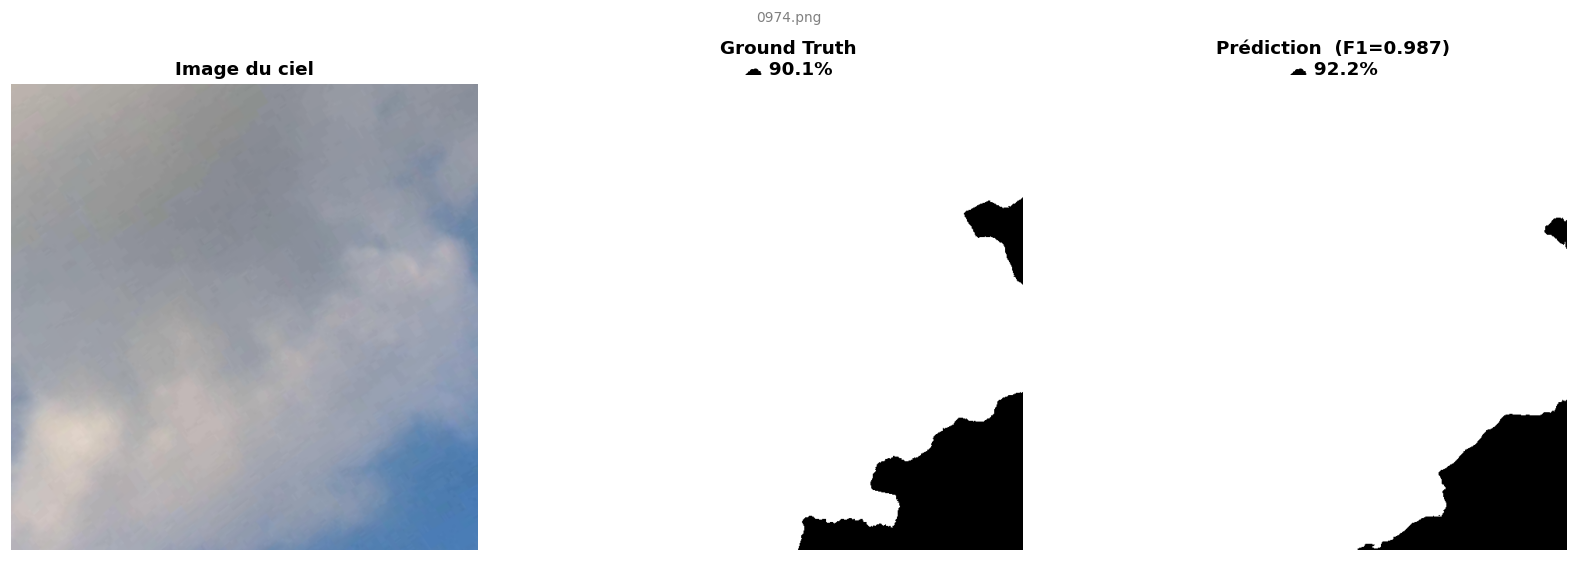

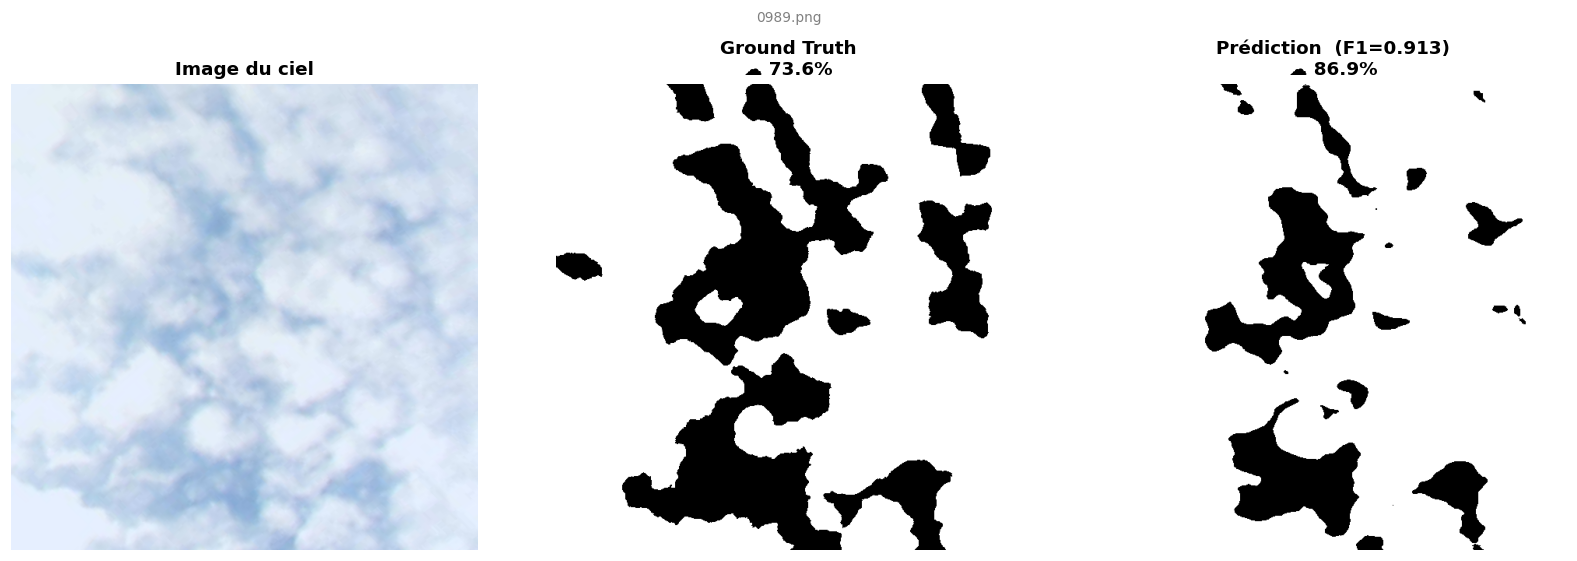

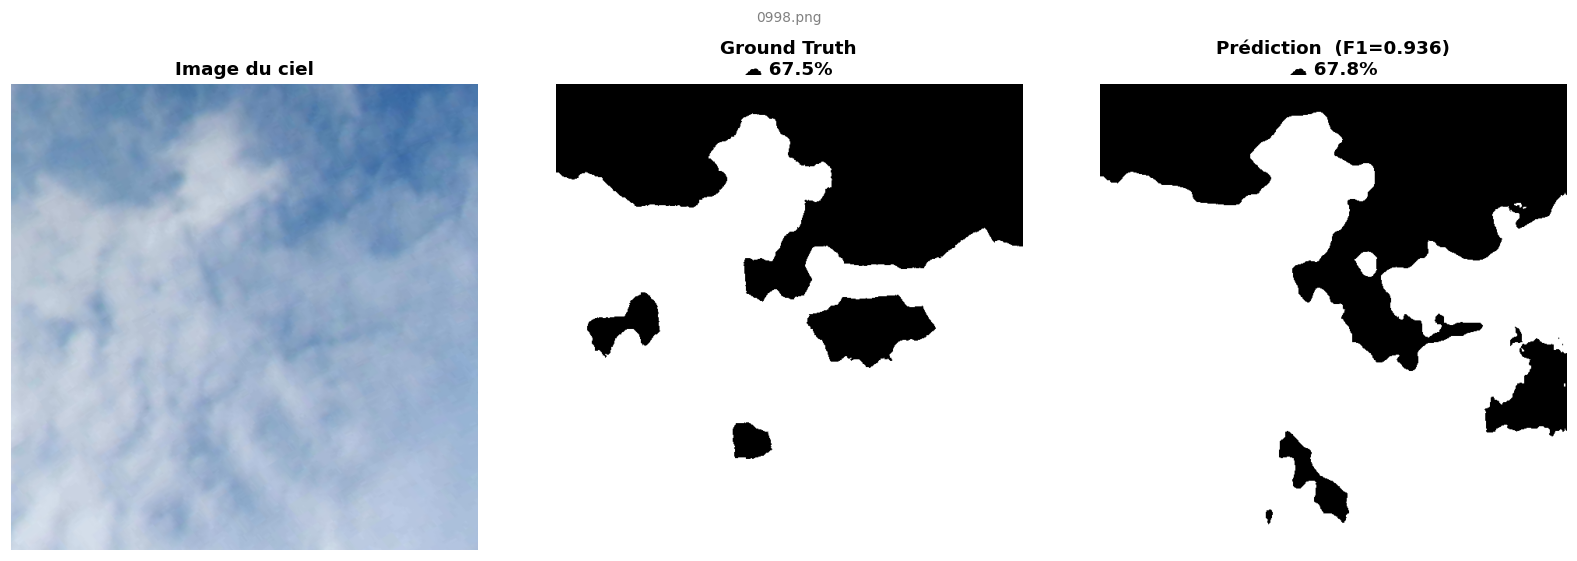

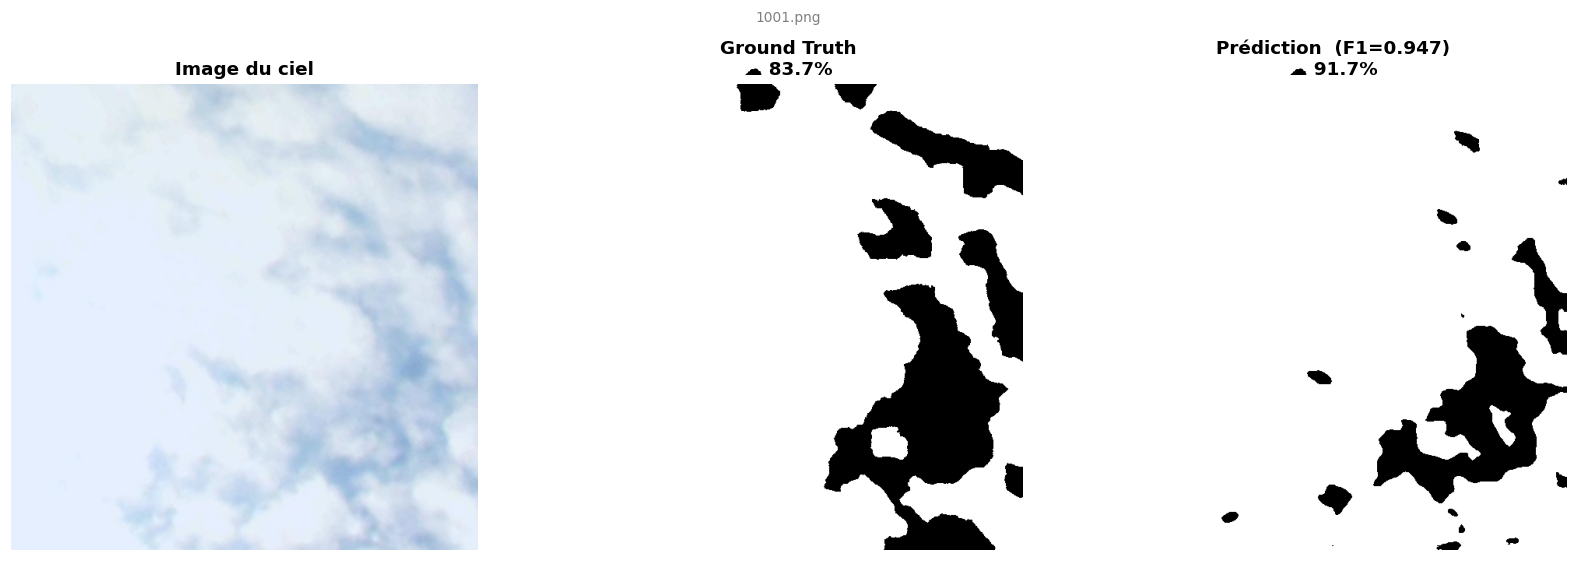

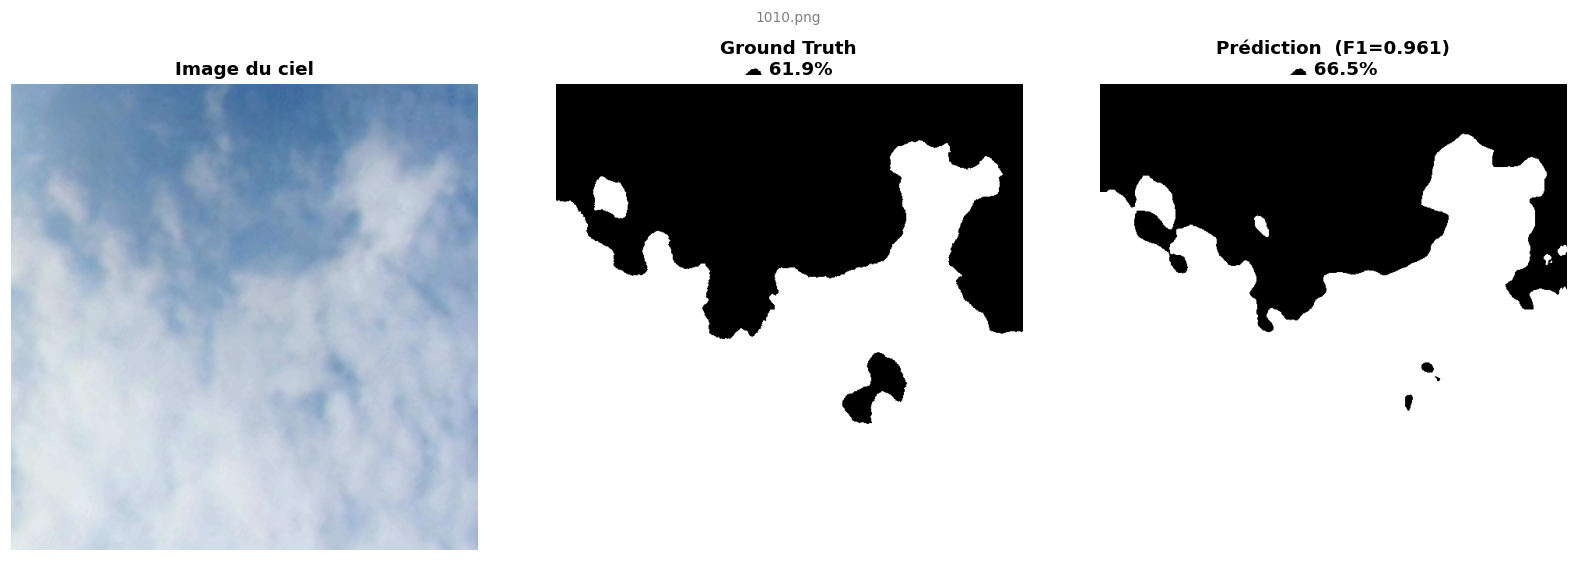

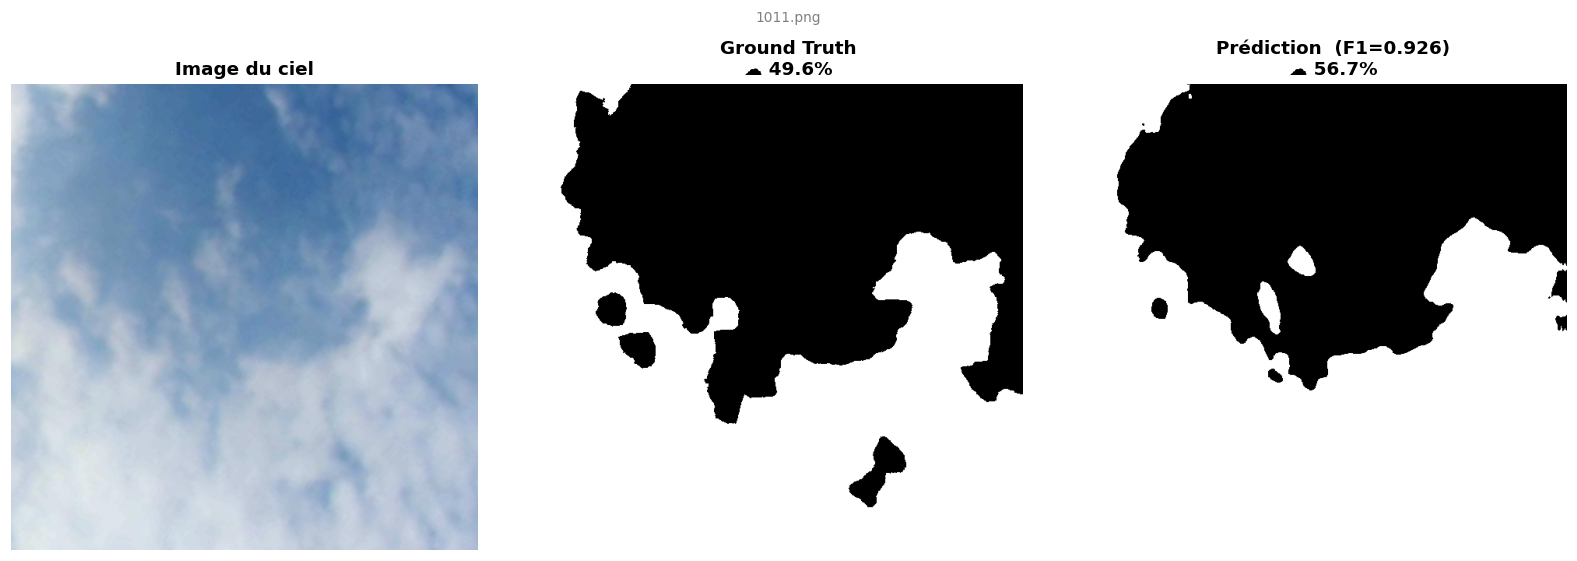

In [6]:
IMG_EXTS   = (".png", ".jpg", ".jpeg", ".bmp")
test_dir   = Path(TEST_DIR)
labels_dir = Path(LABELS_DIR) if LABELS_DIR else None

all_images = sorted(p for p in test_dir.iterdir() if p.suffix.lower() in IMG_EXTS)
print(f"{len(all_images)} images dans le dossier test.")

random.seed(SEED)
selected = sorted(random.sample(all_images, min(N_IMAGES, len(all_images))))

for img_path in selected:
    bgr = cv2.imread(str(img_path))
    if bgr is None:
        print(f"  [skip] {img_path.name}")
        continue

    pred_mask, _ = predict_mask(model, bgr, TRANSFORM, DEVICE, THRESHOLD)

    gt_mask = None
    if labels_dir is not None:
        gt_file = labels_dir / img_path.name
        if gt_file.exists():
            gt_mask = load_gt(gt_file)

    show_comparison(bgr, pred_mask, gt_mask, filename=img_path.name)

## Statistiques globales sur le jeu de test

F1 et couverture nuageuse sur **toutes** les images de test.

In [7]:
print("Calcul des métriques sur tout le jeu de test...")

results = []
for img_path in all_images:
    bgr = cv2.imread(str(img_path))
    if bgr is None:
        continue

    pred_mask, _ = predict_mask(model, bgr, TRANSFORM, DEVICE, THRESHOLD)
    cov_pred = coverage(pred_mask)
    row = {"name": img_path.name, "cov_pred": cov_pred}

    if labels_dir is not None:
        gt_file = labels_dir / img_path.name
        if gt_file.exists():
            gt = load_gt(gt_file)
            if gt is not None:
                gt_r  = cv2.resize(gt, (pred_mask.shape[1], pred_mask.shape[0]),
                                   interpolation=cv2.INTER_NEAREST)
                inter = int((pred_mask & gt_r).sum())
                row["f1"]     = (2 * inter + 1e-7) / (pred_mask.sum() + gt_r.sum() + 1e-7)
                row["cov_gt"] = coverage(gt)

    results.append(row)

covs = [r["cov_pred"] for r in results]
f1s  = [r["f1"] for r in results if "f1" in r]

print(f"\nImages traitées : {len(results)}")
print(f"Couverture nuageuse prédite  — moyenne: {np.mean(covs):.1f}%  "
      f"min: {min(covs):.1f}%  max: {max(covs):.1f}%")
if f1s:
    print(f"F1   — moyenne: {np.mean(f1s):.4f}  "
          f"min: {min(f1s):.4f}  max: {max(f1s):.4f}")

Calcul des métriques sur tout le jeu de test...

Images traitées : 51
Couverture nuageuse prédite  — moyenne: 74.0%  min: 19.8%  max: 100.0%
F1   — moyenne: 0.9350  min: 0.8149  max: 0.9904


## Scatter plot : couverture prédite vs ground truth

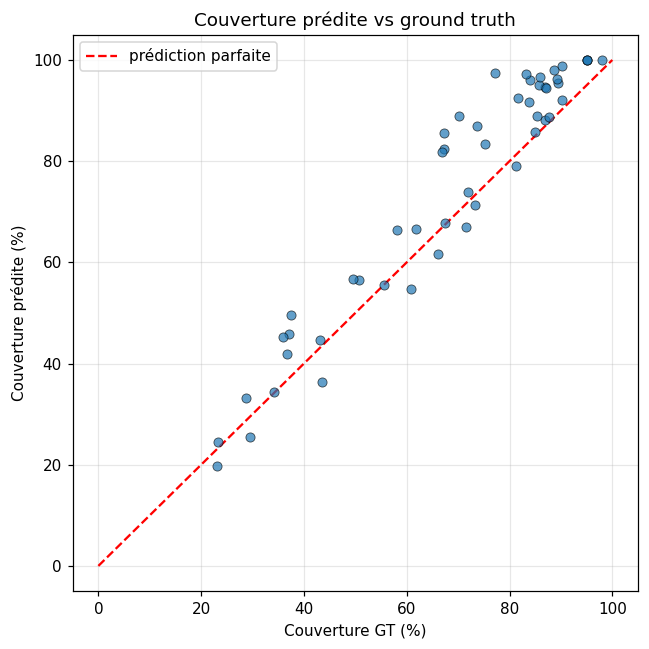

In [8]:
if results and "cov_gt" in results[0]:
    cov_gt_list   = [r["cov_gt"]   for r in results if "cov_gt" in r]
    cov_pred_list = [r["cov_pred"] for r in results if "cov_gt" in r]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(cov_gt_list, cov_pred_list, alpha=0.7, edgecolors="k",
               linewidths=0.5, zorder=3)
    ax.plot([0, 100], [0, 100], "r--", label="prédiction parfaite")
    ax.set_xlabel("Couverture GT (%)")
    ax.set_ylabel("Couverture prédite (%)")
    ax.set_title("Couverture prédite vs ground truth")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Pas de labels GT disponibles pour le scatter plot.")

## Distribution du F1 sur le jeu de test

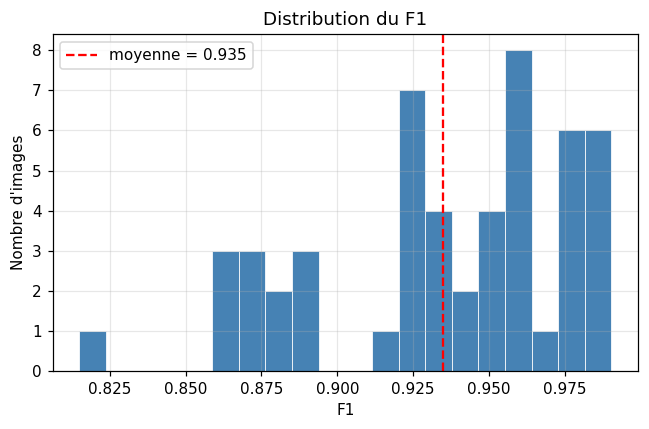

In [9]:
if f1s:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(f1s, bins=20, color="steelblue", edgecolor="white", linewidth=0.5)
    ax.axvline(np.mean(f1s), color="red", linestyle="--",
               label=f"moyenne = {np.mean(f1s):.3f}")
    ax.set_xlabel("F1")
    ax.set_ylabel("Nombre d'images")
    ax.set_title("Distribution du F1")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Pas de labels GT disponibles pour la distribution F1.")

## Courbes d'entraînement

Affiche les courbes loss/IoU sauvegardées pendant le training.

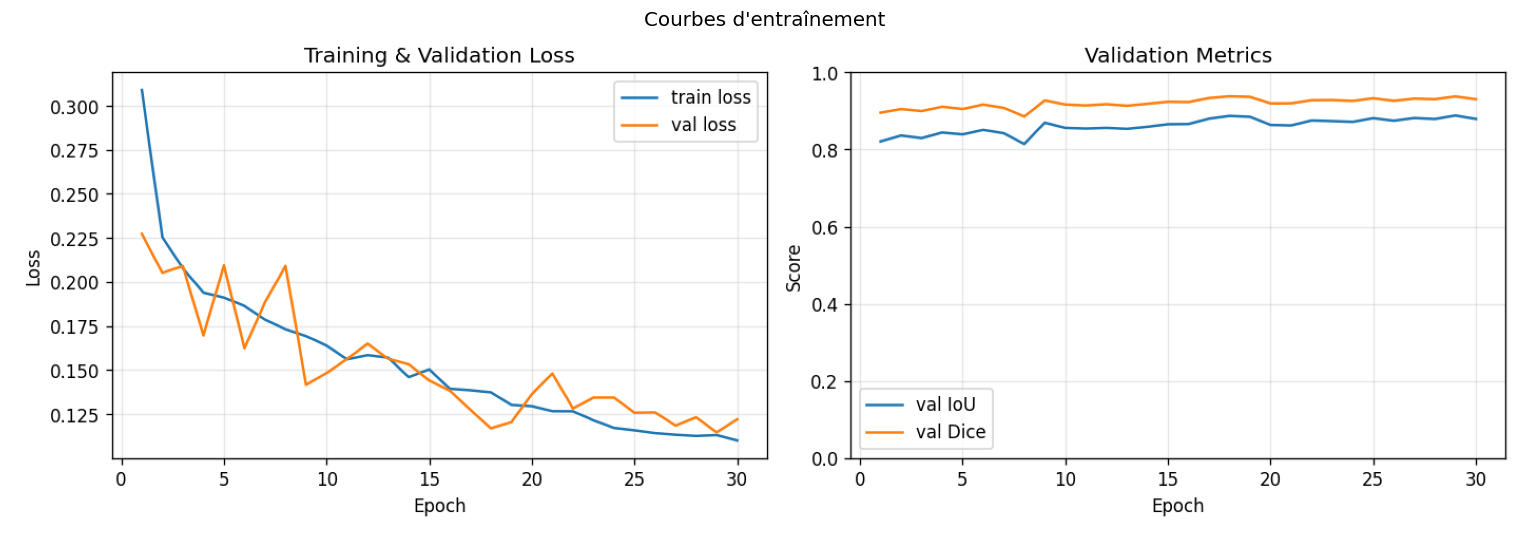

In [10]:
curves_path = "./checkpoints/training_curves.png"
if Path(curves_path).exists():
    img = plt.imread(curves_path)
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Courbes d'entraînement", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print(f"Fichier non trouvé : {curves_path}")
    print("Lance d'abord train.py pour générer les courbes.")